In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [88]:
DATA_PATH = "../data/Gold_features.csv"

FEATURE_COLUMNS = [
    "Close",
    "Volume",
    "RSI",
    "MACD",
    "MACD_Signal",
    "EMA_20",
    "BB_High",
    "BB_Low",
    "ATR"
]

TARGET_COLUMN = "Close"

TIME_STEPS = 60
TRAIN_SIZE = 0.8

In [89]:
def create_sequences(features, target, time_steps):
    X = []
    y = []

    for i in range(time_steps, len(features)):

        # dane wejściowe (60 dni)
        X.append(features[i - time_steps:i])

        # wartość do przewidzenia
        y.append(target[i])

    return np.array(X), np.array(y)

In [90]:
# Wczytanie prawdziwych danych złota

df = pd.read_csv(DATA_PATH)

print(df.head())
print(df.shape)

         Date        Close         High          Low         Open  Volume  \
0  2021-07-02  1782.599976  1787.900024  1778.300049  1778.699951      23   
1  2021-07-06  1793.500000  1809.800049  1786.699951  1786.699951     332   
2  2021-07-07  1801.500000  1808.400024  1797.199951  1798.699951     244   
3  2021-07-08  1799.599976  1818.500000  1797.000000  1797.000000     148   
4  2021-07-09  1810.000000  1810.099976  1798.800049  1803.599976     218   

         RSI       MACD  MACD_Signal       EMA_20      BB_High       BB_Low  \
0  35.587612 -27.457680   -27.827951  1806.885581  1920.740810  1713.039207   
1  40.806028 -25.094853   -27.281332  1805.610764  1909.247186  1714.202826   
2  44.368390 -22.319477   -26.288961  1805.219263  1897.489386  1716.890631   
3  43.695794 -20.042254   -25.039619  1804.684093  1883.740224  1721.279796   
4  48.314390 -17.200071   -23.471710  1805.190369  1867.994074  1728.605950   

         ATR  
0  19.587173  
1  20.130951  
2  19.757314  
3 

In [91]:
# Skalowanie danych

feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

# cechy wejściowe X
scaled_features = feature_scaler.fit_transform(
    df[FEATURE_COLUMNS]
)

# wartość przewidywana Y
scaled_target = target_scaler.fit_transform(
    df[[TARGET_COLUMN]]
)

print("scaled_features shape:", scaled_features.shape)
print("scaled_target shape:", scaled_target.shape)

scaled_features shape: (1225, 9)
scaled_target shape: (1225, 1)


In [92]:
# Tworzenie sekwencji czasowych

X, y = create_sequences(
    scaled_features,
    scaled_target,
    TIME_STEPS
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1165, 60, 9)
y shape: (1165, 1)


In [93]:
# Podział train/test

train_size = int(len(X) * TRAIN_SIZE)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (932, 60, 9)
y_train: (932, 1)
X_test: (233, 60, 9)
y_test: (233, 1)


In [94]:
from tensorflow.keras.models import Sequential
# ADDED: Bidirectional import
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam

# 1. Build the advanced Bidirectional model
model = Sequential()

# We wrap our first LSTM layer with Bidirectional()
# It will read the 60-day sequences in both directions!
model.add(
    Bidirectional(
        LSTM(units=32, return_sequences=True),
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)
model.add(Dropout(0.3))

# Second layer remains a standard LSTM
model.add(
    LSTM(
        units=32,
        return_sequences=False
    )
)
model.add(Dropout(0.3))

# Dense layer
model.add(Dense(16, activation="relu"))

# Output layer
model.add(Dense(1))

# 2. Custom Optimizer (keeping it slow and steady)
custom_optimizer = Adam(learning_rate=0.0005)

# 3. Compile
model.compile(
    optimizer=custom_optimizer,
    loss="mean_squared_error"
)

# You will notice in the summary that the first layer now has 64 units
# (32 for forward + 32 for backward analysis)
model.summary()

C:\Users\Antek\Desktop\University\IV term\PROJ Sztuczna inteligencja\stock-price-prediction-lstm\venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 60, 64)         │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,713 (92.63 KB)

 Trainable params: 23,713 (92.63 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
# 1. Define the safety fuse (Early Stopping)
# monitor='val_loss': Watch the validation error
# patience=10: If it does not improve for 10 epochs, stop training
# restore_best_weights=True: Roll back to the best version of the model
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# 2. Train the model safely
# We can now set a high number of epochs (e.g., 100)
# because EarlyStopping will stop it automatically if needed.
history = model.fit(
    X_train,
    y_train,
    epochs=100,  # Increased from 20 to 100
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],  # Added our safety fuse here
    verbose=1
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0125 - val_loss: 0.0851
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0026 - val_loss: 0.0214
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0020 - val_loss: 0.0093
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0014 - val_loss: 0.0135
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0013 - val_loss: 0.0154
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0012 - val_loss: 0.0129
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0011 - val_loss: 0.0126
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0012 - val_loss: 0.0126
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0010 - val_loss: 0.0175
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0011 - val_loss: 0.0055
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 8.9142e-04 - val_loss: 0.0119
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/

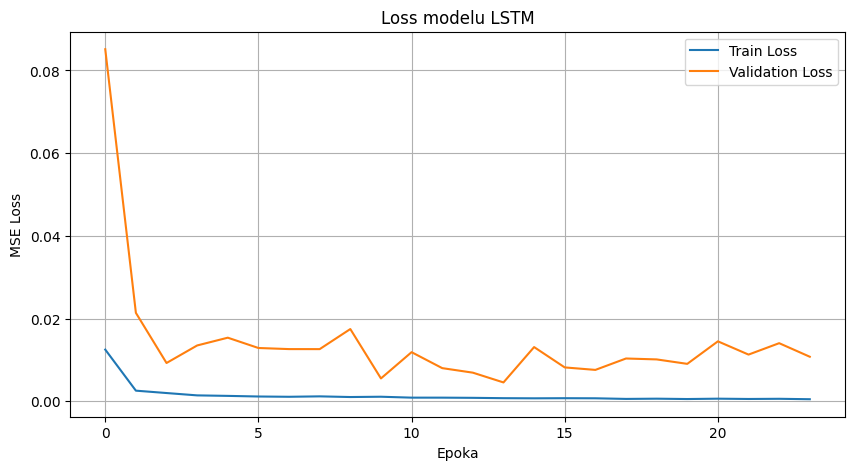

In [82]:
# Wykres strat modelu

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss modelu LSTM")
plt.xlabel("Epoka")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid(True)

plt.show()

In [83]:
# Predykcje modelu

y_pred_scaled = model.predict(X_test)

print(y_pred_scaled[:5])

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
[[0.5019225 ]
 [0.5047913 ]
 [0.50778145]
 [0.510654  ]
 [0.5134014 ]]


In [84]:
# Zamiana z powrotem na prawdziwe ceny

y_pred = target_scaler.inverse_transform(y_pred_scaled)

y_test_real = target_scaler.inverse_transform(y_test)

print("Predykcje:")
print(y_pred[:5])

print("\nRzeczywiste wartości:")
print(y_test_real[:5])

Predykcje:
[[3477.9539]
 [3488.5544]
 [3499.6033]
 [3510.2175]
 [3520.3694]]

Rzeczywiste wartości:
[[3431.19995117]
 [3396.39990234]
 [3386.60009766]
 [3389.80004883]
 [3368.10009766]]


In [96]:
mse = mean_squared_error(y_test_real, y_pred)
mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 62366.698145054695
RMSE: 249.73325398323448
MAE: 185.63754128386535


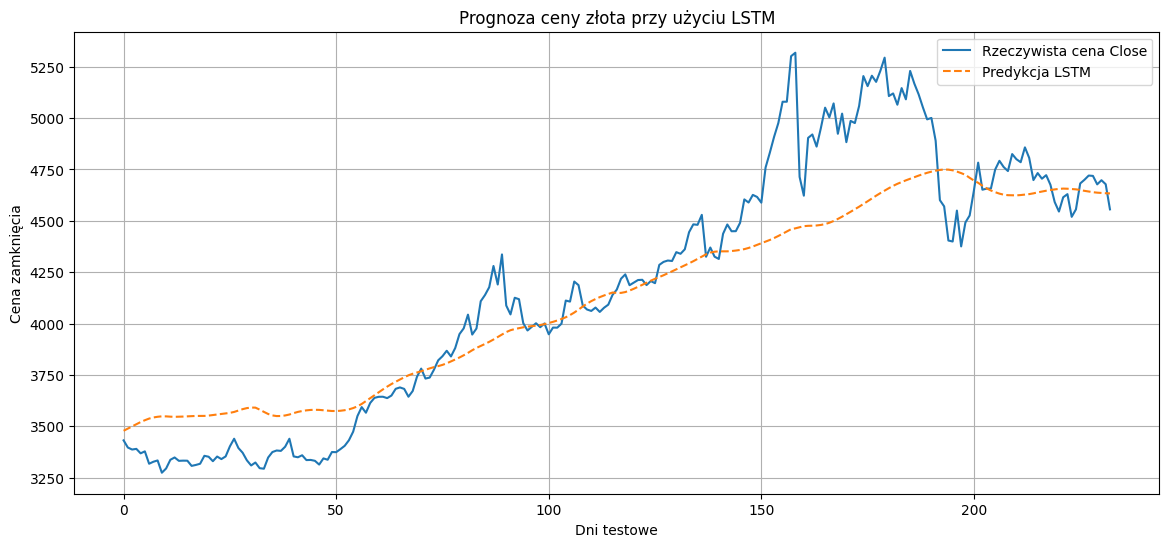

In [86]:
plt.figure(figsize=(14, 6))

plt.plot(y_test_real, label="Rzeczywista cena Close")
plt.plot(y_pred, label="Predykcja LSTM", linestyle="--")

plt.title("Prognoza ceny złota przy użyciu LSTM")
plt.xlabel("Dni testowe")
plt.ylabel("Cena zamknięcia")
plt.legend()
plt.grid(True)

plt.show()